# RNN Retrain - Best Hyperparameters
### Anaerobic Digestion of Olive Mill Waste - Crete Case Study

---

## Results from the RNN K-Fold Search and why this retrain

the K-Fold search evaluated 45 combinations of hidden dimension, learning rate,
and batch size across 6 folds each

**best combination:**

| hyperparameter | 1st Run | K-Fold best |
|----------------|-----------|-------------|
| hidden_dim | 20 | 30 |
| learning rate | 0.001 | 0.001 |
| batch size | 50 | 25 |
| avg val loss | approx 0.000138 | 0.000102 |
| std val loss | not recorded | 0.000016 |

**key findings:**

larger hidden dimensions see to be wiining consistently. the top 4 combos all used
hidden_dim of 25 or 30 (hidden_dim=10 appeared only in the worst combinations)
possible interpretation: a longer sequence of 12 timesteps contains
more info about the digester trajectory so a larger hidden state is
needed to encode that temporal history

learning rate 0.001 dominated the top results (same as with the ANN)
learning rate 0.0001 was too slow for 100 epochs / fold and produced poor results across all hidden dimensions

batch size 25 outperformed batch size 50 and 100. this is smaller than the
ANN optimal batch (50). the RNN has more parameters (603 vs 483) and a
smaller training set (648 clean sequences vs 27,000 individual rows), so
smaller batches provide more gradient updates per epoch and compensate for
the reduced data volume 

the standard deviation of 0.000016 for the best combination is the lowest
of the entire search. this is important since low std across folds means the
model generalises consistently regardless of which data it sees, rather than
performing well on one fold by chance.

**this retrain is built differently from the K-Fold - why:**

the K-Fold used the 648 clean sequences from STANDARDISATION_REF for speed.
this retrain uses all 16,200 augmented sequences from the full training set,
giving the model more data to learn from. K-Fold is for comparing
architectures, retrain is for building the best possible model

the epoch count is increased to 300. the 1st training run converged fully
by epoch 20, but that was on augmented data with a different random seed
and a smaller hidden state. with hidden_dim=30 and more parameters, slightly
more training time is allocated to ensure full convergence

the goal of this retrain is to beat the 1st run loss of 0.000138 and
produce a model that generalises well in the offline testing framework

---


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch version: 2.11.0
cuda available: False


## 2. Hyperparameters

In [2]:
# best hyperparameters from K-Fold search
input_dim  = 5
hidden_dim = 30     # was 20 in first run (K-Fold showed larger is better)
layer_dim  = 1
output_dim = 3

seq_len      = 12
N            = 25       # batch size: smaller than ANN (50) because sequence dataset is smaller
learning_rate= 1e-3     # confirmed best by K-Fold
train_epochs = 300      # more than 1st run to ensure full convergence

print("hyperparameters:")
print(f"  architecture : RNNModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print(f"  sequence len : {seq_len}")
print(f"  batch size   : {N}")
print(f"  learning rate: {learning_rate}")
print(f"  epochs       : {train_epochs}")
params = hidden_dim * (input_dim + hidden_dim + 1) + output_dim * (hidden_dim + 1)
print(f"  parameters   : {params}")
print(f"  (first run had 603 parameters with hidden_dim=20)")

hyperparameters:
  architecture : RNNModel(5, 30, 1, 3)
  sequence len : 12
  batch size   : 25
  learning rate: 0.001
  epochs       : 300
  parameters   : 1173
  (first run had 603 parameters with hidden_dim=20)


## 3. Load Data

In [3]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    data_ref.append([r[c] for c in range(8)])

print(f"reference data : {len(data_ref)} rows")

reference data : 1080 rows


## 4. Standardise

In [4]:
scaler = StandardScaler()
scaler.fit(data_ref)

print("scaler fitted")
print("means: ", [round(m, 3) for m in scaler.mean_])
print("stds:  ", [round(s, 3) for s in scaler.scale_])

scaler fitted
means:  [np.float64(17.244), np.float64(6747.284), np.float64(7.109), np.float64(36.25), np.float64(3.333), np.float64(-0.928), np.float64(352.734), np.float64(-0.013)]
stds:   [np.float64(12.582), np.float64(4702.294), np.float64(0.156), np.float64(4.38), np.float64(2.055), np.float64(0.754), np.float64(286.686), np.float64(0.016)]


## 5. Create Sequences from Full Augmented Data

this retrain uses all 16,200 augmented sequences and not just the 648
clean ones used in K-Fold. idea: more data, better generalisation


In [5]:
std_ref  = scaler.transform(data_ref)
x_ref    = std_ref[:, 0:5]
y_ref    = std_ref[:, 5:8]

n_runs       = 36
rows_per_run = 30

# create clean sequences first
sequences_x = []
sequences_y = []

for run_i in range(n_runs):
    start = run_i * rows_per_run
    end   = start + rows_per_run
    run_x = x_ref[start:end]
    run_y = y_ref[start:end]
    for t in range(rows_per_run - seq_len):
        sequences_x.append(run_x[t : t + seq_len])
        sequences_y.append(run_y[t + seq_len - 1])

sequences_x = np.array(sequences_x)
sequences_y = np.array(sequences_y)

print(f"clean sequences: {sequences_x.shape}")

# augment x25 with Gaussian noise
NOISE_LEVEL  = 0.05 * 0.333
REPLICATIONS = 25

aug_x = []
aug_y = []

for i in range(len(sequences_x)):
    base_x = sequences_x[i]
    base_y = sequences_y[i]
    for _ in range(REPLICATIONS):
        noisy_x = np.random.normal(base_x, np.abs(base_x) * NOISE_LEVEL + 1e-6)
        noisy_y = np.random.normal(base_y, np.abs(base_y) * NOISE_LEVEL + 1e-6)
        aug_x.append(noisy_x)
        aug_y.append(noisy_y)

aug_x = np.array(aug_x)
aug_y = np.array(aug_y)

# shuffle
idx   = np.random.permutation(len(aug_x))
aug_x = aug_x[idx]
aug_y = aug_y[idx]

x_train = torch.tensor(aug_x, dtype=torch.float32)
y_train = torch.tensor(aug_y, dtype=torch.float32)

print(f"augmented sequences: {x_train.shape}")
print(f"augmented targets  : {y_train.shape}")

clean sequences: (648, 12, 5)
augmented sequences: torch.Size([16200, 12, 5])
augmented targets  : torch.Size([16200, 3])


## 6. Define Model

In [6]:
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(RNNModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim,
                          batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        out, hn = self.rnn(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out

model   = RNNModel(input_dim, hidden_dim, layer_dim, output_dim)
loss_fn = nn.MSELoss(reduction='mean')

print("model:")
print(model)
print()
actual_params = sum(p.numel() for p in model.parameters())
print(f"actual parameters: {actual_params}")
test = model(x_train[:N])
print(f"forward pass OK   : output shape {test.shape}")

model:
RNNModel(
  (rnn): RNN(5, 30, batch_first=True)
  (fc): Linear(in_features=30, out_features=3, bias=True)
)

actual parameters: 1203
forward pass OK   : output shape torch.Size([25, 3])


## 7. DataLoader

In [7]:
dataset    = torch.utils.data.TensorDataset(x_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=N, shuffle=True)

print(f"dataset size  : {len(dataset)} sequences")
print(f"batch size    : {N}")
print(f"batches/epoch : {len(dataloader)}")
print(f"gradient updates per epoch: {len(dataloader)}")
print(f"  (first run had {len(dataset)//50} with batch=50)")

dataset size  : 16200 sequences
batch size    : 25
batches/epoch : 648
gradient updates per epoch: 648
  (first run had 324 with batch=50)


In [8]:
optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

model.train()
print(f"training: {train_epochs} epochs, lr={learning_rate}, batch={N}")
print("-" * 58)

for epoch in range(train_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / len(dataloader)
    loss_history.append(epoch_loss)
    if epoch % 25 == 0 or epoch == train_epochs - 1:
        print(f"epoch {epoch:>4d}   loss = {epoch_loss:.7f}")

print("-" * 58)
print(f"done.")
print(f"final loss      : {loss_history[-1]:.7f}")
print(f"first run loss  : 0.0001380")
print(f"improvement     : {((0.0001380 - loss_history[-1])/0.0001380)*100:.1f}%")

training: 300 epochs, lr=0.001, batch=25
----------------------------------------------------------
epoch    0   loss = 0.0184995
epoch   25   loss = 0.0001975
epoch   50   loss = 0.0001811
epoch   75   loss = 0.0001609
epoch  100   loss = 0.0001595
epoch  125   loss = 0.0001563
epoch  150   loss = 0.0001485
epoch  175   loss = 0.0001487
epoch  200   loss = 0.0001417
epoch  225   loss = 0.0001415
epoch  250   loss = 0.0001394
epoch  275   loss = 0.0001363
epoch  299   loss = 0.0001371
----------------------------------------------------------
done.
final loss      : 0.0001371
first run loss  : 0.0001380
improvement     : 0.7%


## 8. Loss Curve

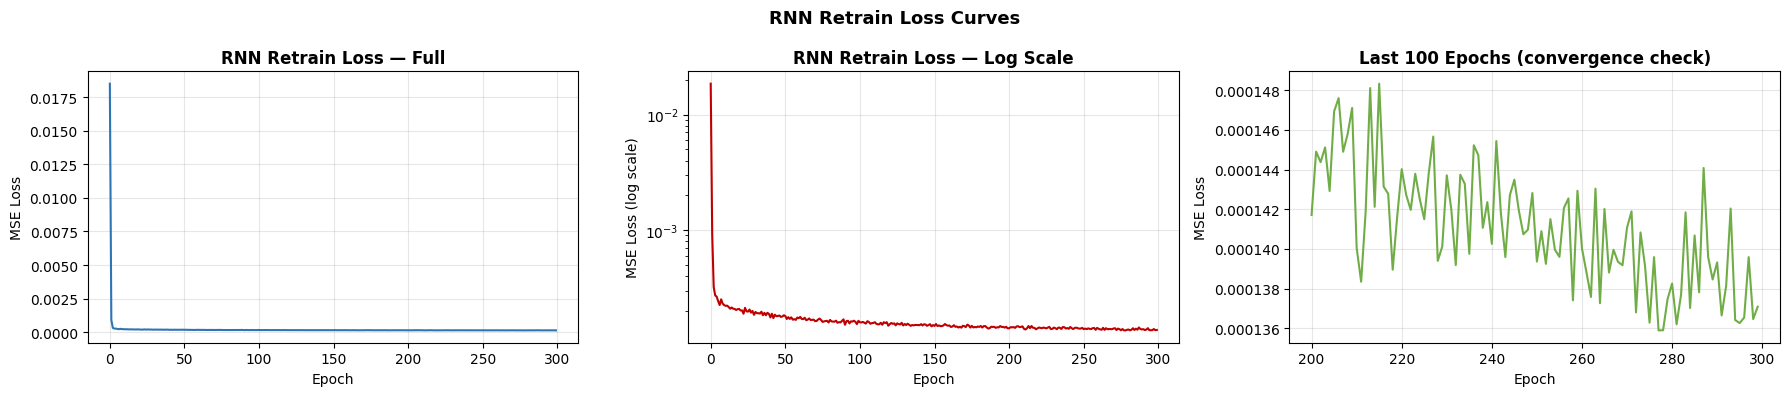

loss drop in last  50 epochs: 0.00000228
loss drop in last 100 epochs: 0.00000462
CONVERGED


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_history, color='#2E75B6', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('RNN Retrain Loss — Full', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_history, color='#C00000', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('RNN Retrain Loss — Log Scale', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(train_epochs-100, train_epochs),
             loss_history[-100:], color='#70AD47', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Last 100 Epochs (convergence check)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('RNN Retrain Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

last50_drop  = loss_history[-50]  - loss_history[-1]
last100_drop = loss_history[-100] - loss_history[-1]
print(f"loss drop in last  50 epochs: {last50_drop:.8f}")
print(f"loss drop in last 100 epochs: {last100_drop:.8f}")
if last50_drop < 0.000005:
    print("CONVERGED")
elif last50_drop < 0.00002:
    print("nearly converged")
else:
    print("still decreasing — consider more epochs")

## 9. Predicted vs Actual

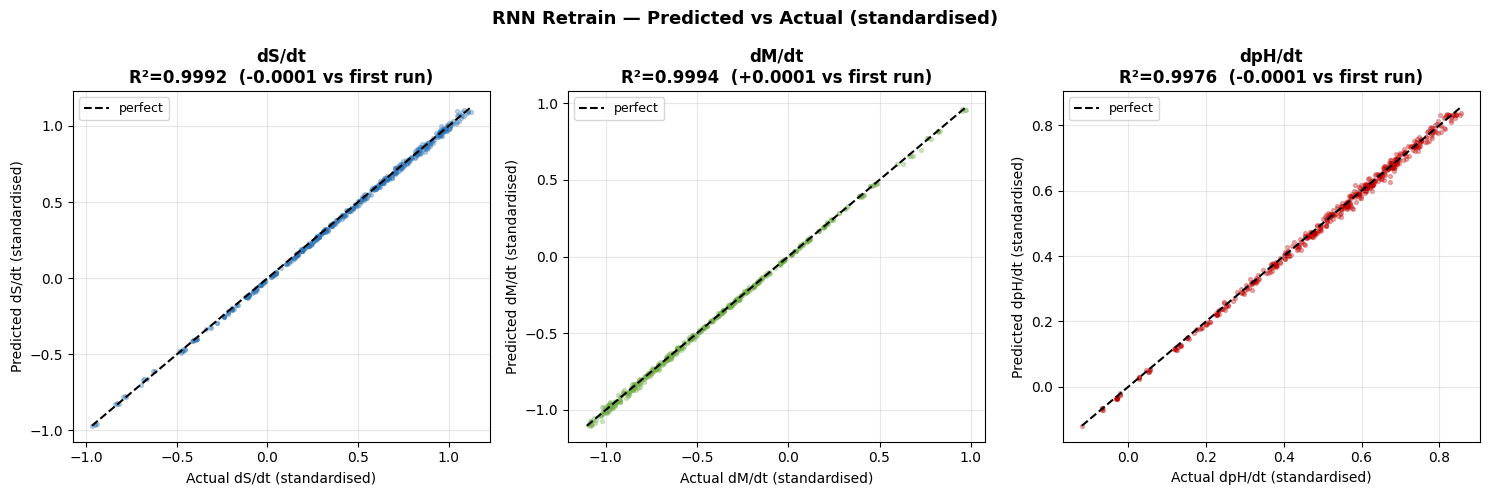

R² comparison (retrain vs first run):
                First Run      Retrain     Change
-----------------------------------------------
  dS/dt            0.9993       0.9992    -0.0001
  dM/dt            0.9993       0.9994    +0.0001
  dpH/dt           0.9977       0.9976    -0.0001


In [10]:
model.eval()
with torch.no_grad():
    sample_x = x_train[:500]
    sample_y = y_train[:500]
    preds    = model(sample_x)

preds_np  = preds.numpy()
actual_np = sample_y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_names = ['dS/dt', 'dM/dt', 'dpH/dt']
colors = ['#2E75B6', '#70AD47', '#C00000']
first_run_r2 = [0.9993, 0.9993, 0.9977]

r2_vals = []
for i, (ax, name, col, fr2) in enumerate(
        zip(axes, target_names, colors, first_run_r2)):
    ax.scatter(actual_np[:, i], preds_np[:, i],
               alpha=0.3, s=8, color=col)
    lims = [min(actual_np[:,i].min(), preds_np[:,i].min()),
            max(actual_np[:,i].max(), preds_np[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ss_res = np.sum((actual_np[:,i] - preds_np[:,i])**2)
    ss_tot = np.sum((actual_np[:,i] - actual_np[:,i].mean())**2)
    r2     = 1 - ss_res / ss_tot
    r2_vals.append(r2)
    delta  = r2 - fr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    ax.set_xlabel(f'Actual {name} (standardised)')
    ax.set_ylabel(f'Predicted {name} (standardised)')
    ax.set_title(f'{name}\nR²={r2:.4f}  ({delta_str} vs first run)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('RNN Retrain — Predicted vs Actual (standardised)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("R² comparison (retrain vs first run):")
print(f"{'':12} {'First Run':>12} {'Retrain':>12} {'Change':>10}")
print("-" * 47)
for name, r2, fr2 in zip(target_names, r2_vals, first_run_r2):
    delta = r2 - fr2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    print(f"  {name:<10} {fr2:>12.4f} {r2:>12.4f} {delta_str:>10}")

## 10. Residual Analysis

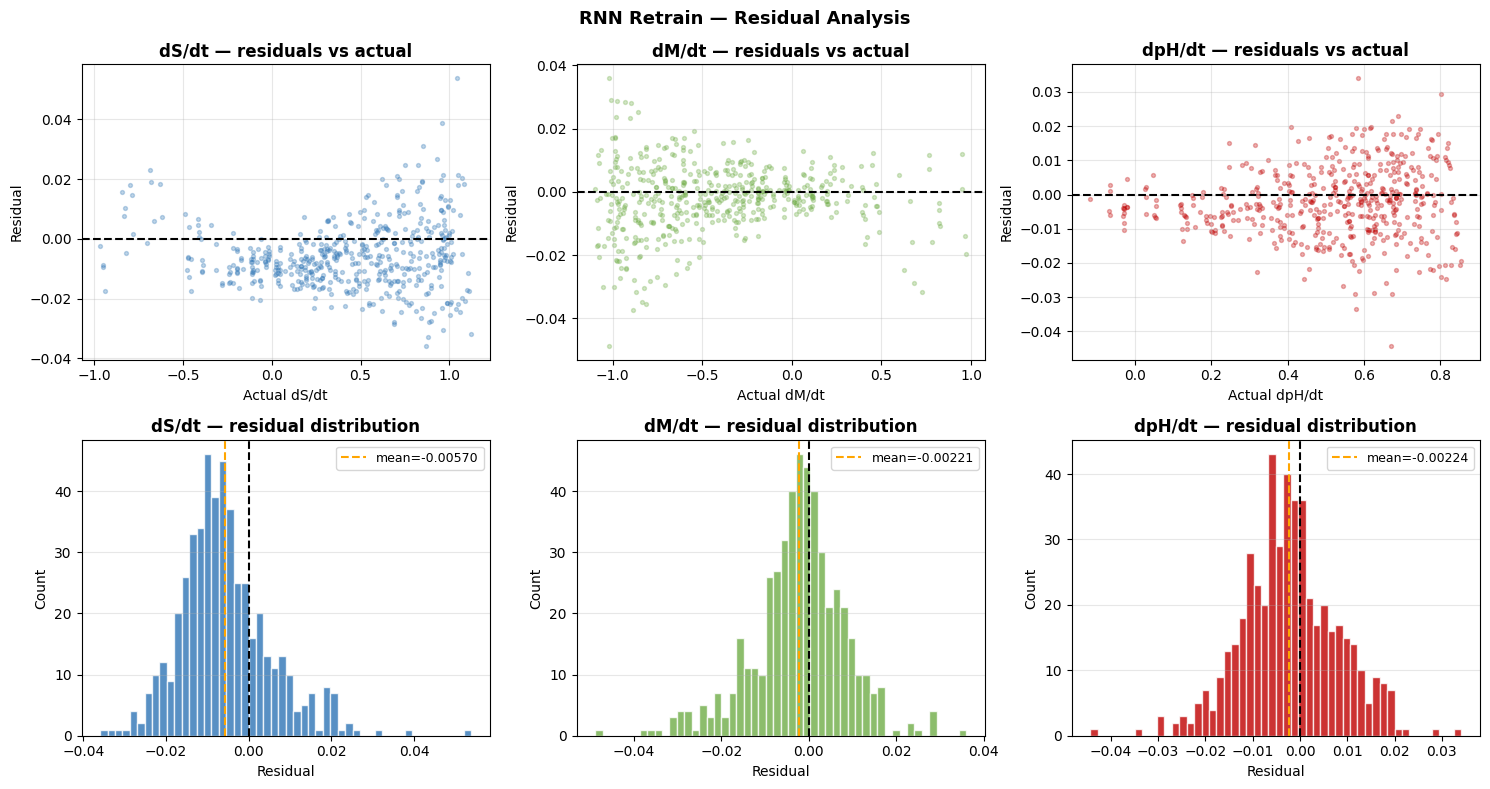

residual means (should be close to 0):
  dS/dt: -0.005700
  dM/dt: -0.002205
  dpH/dt: -0.002239


In [11]:
residuals = preds_np - actual_np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, col) in enumerate(zip(target_names, colors)):
    axes[0, i].scatter(actual_np[:, i], residuals[:, i],
                       alpha=0.3, s=8, color=col)
    axes[0, i].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0, i].set_xlabel(f'Actual {name}')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].set_title(f'{name} — residuals vs actual', fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].hist(residuals[:, i], bins=50, color=col,
                    alpha=0.8, edgecolor='white')
    axes[1, i].axvline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1, i].axvline(residuals[:, i].mean(), color='orange',
                       linewidth=1.5, linestyle='--',
                       label=f'mean={residuals[:,i].mean():.5f}')
    axes[1, i].set_xlabel('Residual')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{name} — residual distribution', fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('RNN Retrain — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("residual means (should be close to 0):")
for i, name in enumerate(target_names):
    print(f"  {name}: {residuals[:,i].mean():.6f}")

## 11. Save Model

In [12]:
torch.save(model.state_dict(), 'RNN_olive_mill_retrained.pt')
np.save('scaler_mean.npy',  scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)

print("saved:")
print("  RNN_olive_mill_retrained.pt")
print("  scaler_mean.npy")
print("  scaler_scale.npy")
print()
print("to reload in testing notebook:")
print(f"  model = RNNModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print("  model.load_state_dict(torch.load('RNN_olive_mill_retrained.pt'))")
print("  model.eval()")

saved:
  RNN_olive_mill_retrained.pt
  scaler_mean.npy
  scaler_scale.npy

to reload in testing notebook:
  model = RNNModel(5, 30, 1, 3)
  model.load_state_dict(torch.load('RNN_olive_mill_retrained.pt'))
  model.eval()


## 12. Summary

In [14]:
actual_params = sum(p.numel() for p in model.parameters())
last50 = loss_history[-50] - loss_history[-1]

print("=" * 60)
print("RNN RETRAIN SUMMARY")
print("=" * 60)
print(f"  architecture  : RNNModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print(f"  parameters    : {actual_params}")
print(f"  sequence len  : {seq_len}")
print(f"  training seqs : {len(x_train)}")
print(f"  epochs        : {train_epochs}")
print(f"  learning rate : {learning_rate}")
print(f"  batch size    : {N}")
print(f"  final loss    : {loss_history[-1]:.7f}")
print(f"  first run loss: 0.0001380")
print(f"  last 50 drop  : {last50:.8f}  ", end="")
print("(converged)" if last50 < 0.000005 else "(still moving slightly)")
print("=" * 60)
print()
print("next step: RNN_Testing_Olive_Mill.ipynb")
print("  online framework: actual state at each timestep")
print("  offline framework: day 0 only, autonomous simulation")
print("  MAPE evaluation: compare to ANN results")

RNN RETRAIN SUMMARY
  architecture  : RNNModel(5, 30, 1, 3)
  parameters    : 1203
  sequence len  : 12
  training seqs : 16200
  epochs        : 300
  learning rate : 0.001
  batch size    : 25
  final loss    : 0.0001371
  first run loss: 0.0001380
  last 50 drop  : 0.00000228  (converged)

next step: RNN_Testing_Olive_Mill.ipynb
  online framework: actual state at each timestep
  offline framework: day 0 only, autonomous simulation
  MAPE evaluation: compare to ANN results
